In [1]:
import warnings
from typing import *

import matplotlib.pyplot as plt
import pandas as pd

from backtest.utils.build_dataset import create_dataset
from backtest.utils.evaluation import (
    compute_equity_curves,
    compute_portfolio_statistics,
    evaluate_experiments_classification,
    evaluate_experiments_topk,
    evaluate_experiments_topk_percent,
    evaluate_experiments_topk_percent_curves,
    get_equity_curve_for_experiment,
    highlight_max,
    random_topk_baseline,
)
from backtest.utils.graphs import (
    plot_bootstrap_ci,
    plot_classification_metrics,
    plot_equity_curves,
    plot_feature_distributions,
    plot_impact_regression,
    plot_pnl_sensitivity,
    plot_robustness_distribution,
    plot_topk_accuracy,
    plot_topk_percent_curves,
)
from backtest.utils.preprocessing import cross_section_standardize
from core.feature_type import FeatureType
from features.FeatureWriter import REGRESSOR_OFFSETS

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Load data from pumps/cross_sections
df: pd.DataFrame = create_dataset()
df["is_pumped"] = df["currency_pair"] == df["pumped_currency_pair"]  # create bool column is_pumped

Building dataset: 100%|██████████| 498/498 [00:05<00:00, 89.05it/s] 
2026-03-25 03:24:07,511 | WARNING | root | No data present for 25 pumps


<h4>Look at the data</h4>

<p>We see that over time the overall cross-section size grows. Meaning it is more difficult to correctly predict which asset will be manipulated</p>

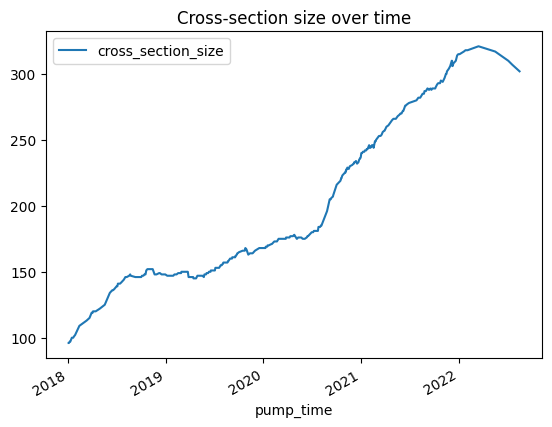

In [3]:
# cross-section statistics
(
    df.groupby("pump_hash")
    .agg(
        pump_time=("pump_time", "first"),
        cross_section_size=("pump_time", "count")
    )
    .sort_values(by="pump_time", ascending=True)
    .plot(x="pump_time", y="cross_section_size", title="Cross-section size over time")
)
plt.show()

<h4>Feature distributions and preprocessing</h4>

<p>Inspect feature statistics, clip/fill missing values, and verify no NaNs remain.</p>

In [4]:
# Define feature column groups
powerlaw_cols: List[str] = FeatureType.POWERLAW_ALPHA.col_names(offsets=REGRESSOR_OFFSETS)
asset_return_cols: List[str] = FeatureType.ASSET_RETURN.col_names(offsets=REGRESSOR_OFFSETS)
asset_return_zscore_cols: List[str] = FeatureType.ASSET_RETURN_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
quote_abs_zscore_cols: List[str] = FeatureType.QUOTE_ABS_ZSCORE.col_names(offsets=REGRESSOR_OFFSETS)
share_of_long_trades_cols: List[str] = FeatureType.SHARE_OF_LONG_TRADES.col_names(offsets=REGRESSOR_OFFSETS)
slippage_imbalance_cols: List[str] = FeatureType.SLIPPAGE_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
flow_imbalance_cols: List[str] = FeatureType.FLOW_IMBALANCE.col_names(offsets=REGRESSOR_OFFSETS)
num_trades_cols: List[str] = FeatureType.NUM_TRADES.col_names(offsets=REGRESSOR_OFFSETS)

all_feature_cols = (
        powerlaw_cols + asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols
        + share_of_long_trades_cols + slippage_imbalance_cols + flow_imbalance_cols + num_trades_cols
)

# Clip powerlaw features to valid range and fill NaNs
df[powerlaw_cols] = df[powerlaw_cols].clip(1, 2).fillna(-1)

# Summary statistics
print(f"Dataset shape: {df.shape}")
print(f"NaN rows remaining: {df[all_feature_cols].isna().any(axis=1).sum()}")
df[all_feature_cols].describe().T[["mean", "std", "min", "max"]]

Dataset shape: (93058, 91)
NaN rows remaining: 48484


,mean,std,min,max
powerlaw_alpha@5MIN,1.263149,0.828647,-1.0,2.0
powerlaw_alpha@15MIN,1.329985,0.461583,-1.0,2.0
powerlaw_alpha@1H,1.261707,0.257130,-1.0,2.0
powerlaw_alpha@2H,1.231099,0.236061,-1.0,2.0
powerlaw_alpha@4H,1.208620,0.226379,-1.0,2.0
...,...,...,...,...
num_trades@12H,4307.020514,10927.010818,0.0,437471.0
num_trades@1D,8453.650895,21268.812450,0.0,855882.0
num_trades@2D,16945.006125,41277.808049,0.0,1302688.0
num_trades@7D,59441.423789,135038.076218,0.0,3823480.0


<h4>Plot feature distributions before and after cross-sectional standardisation</h4>

$$X_{\text{std}} = \frac{X - \bar{X}}{\sigma_{X}}$$

In [ ]:
# Apply cross-sectional standardisation
cols_to_scale: List[str] = asset_return_cols + asset_return_zscore_cols + quote_abs_zscore_cols + powerlaw_cols
df_scaled: pd.DataFrame = cross_section_standardize(df, cols_to_scale=cols_to_scale)
df_scaled.head(2)

In [ ]:
from core.time_utils import NamedTimeDelta

plot_feature_distributions(
    df_raw=df,
    df_scaled=df_scaled,
    feature_types=[FeatureType.ASSET_RETURN, FeatureType.ASSET_RETURN_ZSCORE, FeatureType.QUOTE_ABS_ZSCORE],
    offset=NamedTimeDelta.ONE_DAY,
    n_pumps=5,
    save_path="images/cs_standardization_impact.png",
)

<h4>Split data and train the first model</h4>

In [7]:
from backtest.utils.sample import Sample
from backtest.utils.feature_set import FeatureSet
from backtest.utils.experiment import Experiment

# use manually predefined set of features if we want to add more features we need to make sure to add them to FeatureSet.auto()
# FeatureSet defines the numeric/categorical regressors and target used for training, it is better to have this object passed around instead of multiple sets of features
# that's why we have it
feature_set: FeatureSet = FeatureSet.auto()

<h4>LogisticRegression model</h4>

In [8]:
from backtest.pipelines.LogisticRegression.pipe import LogisticRegressionPipeline
from backtest.pipelines.LogisticRegression.model import LogisticRegressionModel

pipe = LogisticRegressionPipeline()
sample = pipe.create_sample()

model: LogisticRegressionModel = pipe.train(sample=sample, tuned=False)
experiment_lr = Experiment(experiment_name="LogisticRegression", model=model, sample=sample)

model: LogisticRegressionModel = pipe.train(sample=sample, tuned=True)
experiment_lr_tuned = Experiment(experiment_name="LogisticRegression + Tuned", model=model, sample=sample)

2026-03-25 03:24:14,117 | INFO | root | Building dataset and preprocessing data
2026-03-25 03:24:14,117 | INFO | root | Building raw dataset from feature files
Building dataset: 100%|██████████| 498/498 [00:05<00:00, 94.90it/s] 
2026-03-25 03:24:19,921 | WARNING | root | No data present for 25 pumps
2026-03-25 03:24:19,977 | INFO | root | Removing failed pump cross sections
2026-03-25 03:24:20,017 | WARNING | root | Removed 114 failed pumps
2026-03-25 03:24:20,397 | INFO | root | Nans
flow_imbalance@5MIN         0
flow_imbalance@15MIN        0
flow_imbalance@1H           0
flow_imbalance@2H           0
flow_imbalance@4H           0
                           ..
share_of_long_trades@1D     0
share_of_long_trades@2D     0
share_of_long_trades@7D     0
share_of_long_trades@14D    0
num_prev_pump               0
Length: 81, dtype: int64
2026-03-25 03:24:20,721 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-25 03:24:20,721 | INFO | root | Dataset DatasetType.VALIDATION

<h4>RandomForestClassifier</h4>

In [9]:
from backtest.pipelines.RandomForest.pipe import RandomForestPipeline
from backtest.pipelines.RandomForest.model import RandomForestModel

pipe = RandomForestPipeline()
sample: Sample = pipe.create_sample()

model: RandomForestModel = pipe.train(sample, tuned=False)
experiment_rf = Experiment(experiment_name="RandomForestClassifier", model=model, sample=sample)

model: RandomForestModel = pipe.train(sample, tuned=True)
experiment_rf_tuned = Experiment(experiment_name="RandomForestClassifier + Tuned", model=model, sample=sample)

2026-03-25 03:24:25,021 | INFO | root | Building dataset and preprocessing data
2026-03-25 03:24:25,021 | INFO | root | Using cached raw dataset
2026-03-25 03:24:25,053 | INFO | root | Removing failed pump cross sections
2026-03-25 03:24:25,094 | WARNING | root | Removed 114 failed pumps
2026-03-25 03:24:25,466 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-25 03:24:25,466 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-25 03:24:25,467 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
2026-03-25 03:24:25,503 | INFO | root | Training model
2026-03-25 03:24:27,190 | INFO | root | Training model


<h4>CatboostClassifier</h4>

In [10]:
from backtest.pipelines.CatboostClassifier.pipe import CatboostClassifierPipeline
from backtest.pipelines.CatboostClassifier.model import CatboostClassifierModel

pipe = CatboostClassifierPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb = Experiment(experiment_name="CatboostClassifier", model=model, sample=sample)

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_tuned = Experiment(experiment_name="CatboostClassifier + Tuned", model=model, sample=sample)

2026-03-25 03:24:46,644 | INFO | root | Building dataset and preprocessing data
2026-03-25 03:24:46,645 | INFO | root | Using cached raw dataset
2026-03-25 03:24:46,682 | INFO | root | Removing failed pump cross sections
2026-03-25 03:24:46,722 | WARNING | root | Removed 114 failed pumps
2026-03-25 03:24:47,098 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-25 03:24:47,099 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-25 03:24:47,099 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)


<h4>CatboostClassifier + SMOTE</h4>

In [11]:
from backtest.pipelines.CatboostClassifierSMOTE.pipe import CatboostClassifierSMOTEPipeline

pipe = CatboostClassifierSMOTEPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=False)
experiment_cb_smote = Experiment(experiment_name="CatboostClassifier + SMOTE", model=model, sample=sample)

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_smote_tuned = Experiment(experiment_name="CatboostClassifier + SMOTE + Tuned", model=model, sample=sample)

2026-03-25 03:24:48,803 | INFO | root | Building dataset and preprocessing data
2026-03-25 03:24:48,804 | INFO | root | Using cached raw dataset
2026-03-25 03:24:48,837 | INFO | root | Removing failed pump cross sections
2026-03-25 03:24:48,882 | WARNING | root | Removed 114 failed pumps
2026-03-25 03:24:49,575 | INFO | root | Nans
flow_imbalance@5MIN         0
flow_imbalance@15MIN        0
flow_imbalance@1H           0
flow_imbalance@2H           0
flow_imbalance@4H           0
                           ..
share_of_long_trades@1D     0
share_of_long_trades@2D     0
share_of_long_trades@7D     0
share_of_long_trades@14D    0
num_prev_pump               0
Length: 81, dtype: int64
2026-03-25 03:24:49,596 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-25 03:24:49,596 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-25 03:24:49,597 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
2026-03-25 03:24:49,634 | INFO | root | Applying SMO

<h4>CatboostRanker</h4>

In [12]:
from backtest.pipelines.CatboostRanker.pipe import CatboostRankerPipeline
from backtest.pipelines.CatboostRanker.model import CatboostRankerModel

pipe = CatboostRankerPipeline()
sample: Sample = pipe.create_sample()

model: CatboostRankerModel = pipe.train(sample, tuned=False)
experiment_cb_ranker = Experiment(experiment_name="CatboostRanker", model=model, sample=sample)

model: CatboostRankerModel = pipe.train(sample, tuned=True)
experiment_cb_ranker_tuned = Experiment(experiment_name="CatboostRanker + Tuned", model=model, sample=sample)

2026-03-25 03:25:14,015 | INFO | root | Building dataset and preprocessing data
2026-03-25 03:25:14,016 | INFO | root | Using cached raw dataset
2026-03-25 03:25:14,047 | INFO | root | Removing failed pump cross sections
2026-03-25 03:25:14,089 | WARNING | root | Removed 114 failed pumps
2026-03-25 03:25:14,415 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 93)
2026-03-25 03:25:14,416 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 93)
2026-03-25 03:25:14,416 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 93)
2026-03-25 03:25:15,659 | INFO | root | Loading parameters from CatboostRankerPipelineStudy


<h4>CatboostClassifier + TOPKAUC Early stopping</h4>

In [13]:
from backtest.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline

pipe = CatboostClassifierTOPKAUCPipeline()
sample: Sample = pipe.create_sample()

model: CatboostClassifierModel = pipe.train(sample, tuned=True)
experiment_cb_topkauc_tuned = Experiment(experiment_name="CatboostClassifier + TOPKAUC Early Stopping", model=model,
                                         sample=sample)

2026-03-25 03:25:17,696 | INFO | root | Building dataset and preprocessing data
2026-03-25 03:25:17,697 | INFO | root | Using cached raw dataset
2026-03-25 03:25:17,745 | INFO | root | Removing failed pump cross sections
2026-03-25 03:25:17,787 | WARNING | root | Removed 114 failed pumps
2026-03-25 03:25:18,140 | INFO | root | Dataset DatasetType.TRAIN. Shape (35121, 92)
2026-03-25 03:25:18,141 | INFO | root | Dataset DatasetType.VALIDATION. Shape (17479, 92)
2026-03-25 03:25:18,141 | INFO | root | Dataset DatasetType.TEST. Shape (16960, 92)
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7556828	test: 0.8122297	best: 0.8122297 (0)	total: 107ms	remaining: 1m 46s
10:	learn: 0.8704405	test: 0.8902027	best: 0.8937162 (8)	total: 1.1s	remaining: 1m 39s
20:	learn: 0.8859251	test: 0.9062838	best: 0.9062838 (20)	total: 2.29s	remaining: 1m 46s
30:	learn: 0.8982819	test: 0.9089865	best: 0.9102703 (27)	total: 3.32s	remaining: 1m 43s
40:	learn: 0.9053744	test: 0.9136486	best: 0.9136486 (40)	total: 4.35s	remaining: 1m 41s
50:	learn: 0.9078194	test: 0.9159459	best: 0.9166216 (45)	total: 5.3s	remaining: 1m 38s
60:	learn: 0.9137885	test: 0.9150000	best: 0.9166216 (45)	total: 6.45s	remaining: 1m 39s
70:	learn: 0.9165639	test: 0.9181081	best: 0.9181081 (70)	total: 7.51s	remaining: 1m 38s
80:	learn: 0.9213656	test: 0.9200000	best: 0.9200000 (80)	total: 8.57s	remaining: 1m 37s
90:	learn: 0.9227974	test: 0.9225676	best: 0.9228378 (89)	total: 9.71s	remaining: 1m 36s
100:	learn: 0.9262996	test: 0.9239865	best: 0.9240541 (99)	total: 10.8s	remaining: 1m 36s
110:	learn: 0.9321366	tes

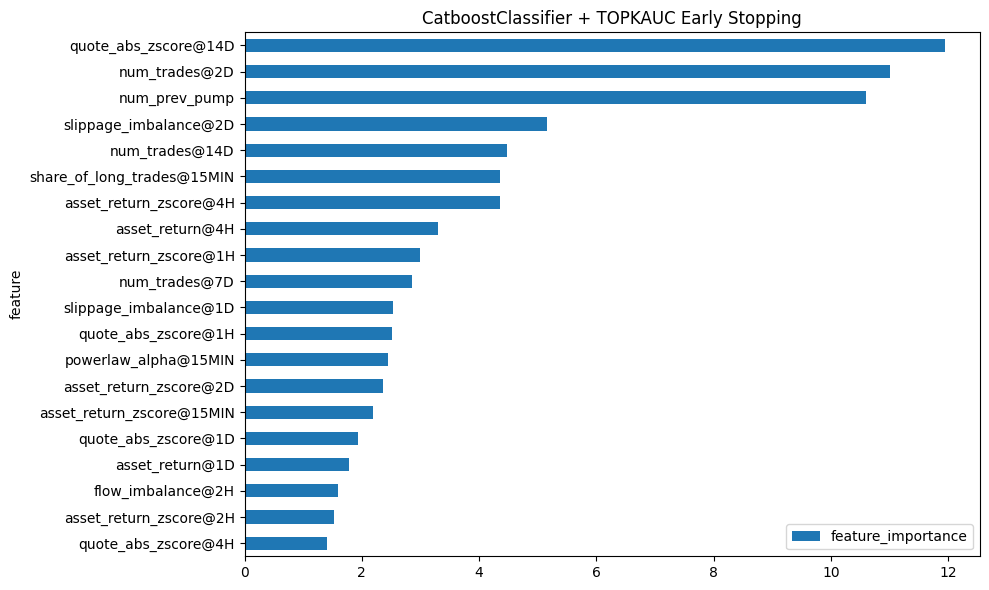

In [14]:
model = experiment_cb_topkauc_tuned.get_model()._model

df_fi = pd.DataFrame({
    "feature": model.feature_names_,
    "feature_importance": model.feature_importances_
})
df_fi = df_fi.set_index("feature").sort_values(by="feature_importance", ascending=True)

df_fi.tail(20).plot.barh(figsize=(10, 6))
plt.title("CatboostClassifier + TOPKAUC Early Stopping")
plt.tight_layout()
plt.savefig("images/feature_importances.png")

<h4>TOPK metric for all models</h4>

In [ ]:
from backtest.utils.sample import DatasetType
from backtest.utils.experiment import Experiment

experiments: List[Experiment] = [
    experiment_lr, experiment_lr_tuned,
    experiment_rf, experiment_rf_tuned,
    experiment_cb, experiment_cb_tuned,
    experiment_cb_smote, experiment_cb_smote_tuned,
    experiment_cb_ranker, experiment_cb_ranker_tuned,
    experiment_cb_topkauc_tuned,
]

In [ ]:
df_topk = evaluate_experiments_topk(experiments)
styled = df_topk.T.style.apply(highlight_max, axis=0)
styled

In [ ]:
cols = [col for col in df_topk.columns if col.endswith("Tuned")] + ["CatboostClassifier + TOPKAUC Early Stopping"]
sample = experiment_cb_topkauc_tuned.get_sample()
baseline = random_topk_baseline(sample.get_dataset(DatasetType.TEST))

plot_topk_accuracy(df_topk, cols=cols, random_baseline=baseline, save_path="images/topk_accuracy_test.png")

<h4>TOPK% for models</h4>

In [ ]:
df_topkp = evaluate_experiments_topk_percent(experiments)
styled = df_topkp.style.apply(highlight_max, axis=1)
styled

<h4>TOPK% curves for all models</h4>

In [ ]:
df_topkp_curves, auc_scores = evaluate_experiments_topk_percent_curves(experiments)
plot_topk_percent_curves(df_topkp_curves, cols=cols, auc_scores=auc_scores, save_path="images/topkp_auc_test.png")

<h4>Classification metrics on TEST</h4>
<p>Alongside ranking metrics, we also report PR-AUC, F1, and balanced accuracy. For F1/balanced accuracy we use the <code>top1_per_cross_section</code> decision rule.</p>

In [ ]:
df_classification_metrics = evaluate_experiments_classification(experiments)
styled = df_classification_metrics.style.apply(highlight_max, axis=0).format("{:.4f}")
styled

In [ ]:
plot_classification_metrics(df_classification_metrics, cols=cols, save_path="images/classification_metrics_test.png")

<h4>Test Sample PnL</h4>

In [ ]:
df_curves = compute_equity_curves(experiments)

In [ ]:
plot_equity_curves(df_curves, cols=cols, save_path="images/portfolios_test.png")

<h4>Portfolio performance for TOPKAUC ES Model</h4>

In [ ]:
curves: Dict[int, pd.Series] = {}
for k in [1, 2, 5, 10, 20, 30]:
    curves[k] = get_equity_curve_for_experiment(experiment=experiment_cb_topkauc_tuned, portfolio_size=k)

In [ ]:
df = pd.concat(curves, axis=1)
df.columns = [1, 2, 5, 10, 20, 30]

df_results = compute_portfolio_statistics(df)
df_results

In [ ]:
plot_equity_curves(
    df,
    title="Cumulative return on the test set for CatboostClassifier + TOPKAUC + ES",
    save_path="images/portfolios_test.png",
)

<h4>Execution-aware PnL with trade-based price impact</h4>
<p>We fit a side-aware price impact model for each traded asset using the previous 14 days of trade-level data. Trades sharing the same execution timestamp are aggregated into meta-orders, binned by notional size (log-spaced), and the median impact per bin is used as a non-parametric impact estimate. Strategy PnL is then recomputed for different intended order sizes.</p>


In [28]:
from datetime import timedelta
from backtest.portfolio.TOPKPortfolio import evaluate_topk_pnl_for_quantities

impact_quantities_usdt = [100, 200, 500, 1000, 2000, 5000, 10000]

dataset_test = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST)

df_pnl_by_quantity = evaluate_topk_pnl_for_quantities(
    model=experiment_cb_topkauc_tuned.get_model(),
    dataset=dataset_test,
    portfolio_size=5,
    quantities_usdt=impact_quantities_usdt,
    buy_before=timedelta(minutes=60),
    sell_after=timedelta(minutes=1),
    impact_lookback_days=14,
    impact_liquidity_quantile=0.9,
)

df_pnl_by_quantity["mean_roe_pct"] = 100.0 * df_pnl_by_quantity["mean_roe"]
df_pnl_by_quantity[["quantity_usdt", "mean_roe_pct"]]

,quantity_usdt,mean_roe_pct
0,100.0,4.069129
1,200.0,3.985695
2,500.0,3.617871
3,1000.0,2.590302
4,2000.0,1.397585
5,5000.0,0.578047
6,10000.0,0.289023


In [ ]:
df_pnl_by_quantity["mean_roe_pct"] = 100.0 * df_pnl_by_quantity["mean_roe"]
plot_pnl_sensitivity(df_pnl_by_quantity, save_path="images/pnl_vs_quantity_with_impact.png")

<h5>Example: fitted sqrt impact model for one pump asset</h5>
<p>Pick one pump asset with sufficient trade history (14-day lookback), aggregate fills by execution time into meta-orders, classify each as buy- or sell-initiated, convert notionals to USDT, and fit: I(Q) = max(0, a + β√Q_usdt) via constrained OLS (β ≥ 0, a unconstrained). Fitting in USDT space ensures the impact curve is comparable across BTC price regimes. A negative intercept creates a dead zone where small orders have zero impact.</p>
<pre>side(order) = +1 if net buy-initiated notional > 0, else -1</pre>
<pre>impact_bps(order) = max(0, side × (price_last / price_first - 1) × 10000)</pre>

In [ ]:
from backtest.utils.impact_example import find_best_impact_example

dataset_test = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST)
example = find_best_impact_example(dataset_test)

samples = example.fit_result.samples[example.fit_result.samples["notional_usdt"] > 0].copy()
plot_impact_regression(
    model=example.fit_result.model,
    samples=samples,
    currency_pair_name=example.currency_pair.name,
    pump_time=example.pump.time,
    save_path="images/impact_regression_example.png",
)

<h4>Robustness checks: train on subset of cross-sections</h4>
<p>We repeatedly train the same pipeline on random subsets of <code>TRAIN</code> cross-sections, evaluate on the fixed <code>TEST</code> split, and collect a distribution of ranking metrics.</p>

In [31]:
from pathlib import Path
from backtest.pipelines.CatboostClassifierTOPKAUC.pipe import CatboostClassifierTOPKAUCPipeline
from backtest.robust.robustness import run_cross_section_subset_robustness, summarise_robustness_distribution

ROBUSTNESS_OUTPUT: Path = Path("analysis_outputs/robustness/catboost_topkauc_subset_runs.csv")

df_robustness: pd.DataFrame = run_cross_section_subset_robustness(
    pipeline_factory=CatboostClassifierTOPKAUCPipeline,
    subset_fraction=0.7,
    n_runs=25,
    tuned=True,
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
    base_seed=42,
    output_path=ROBUSTNESS_OUTPUT,
)

df_robustness.head()

2026-03-25 03:32:47,574 | INFO | root | Using cached preprocessed datasets for CatboostClassifierTOPKAUCPipeline
/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7634277	test: 0.8111486	best: 0.8111486 (0)	total: 90.3ms	remaining: 1m 30s
10:	learn: 0.8661321	test: 0.8895946	best: 0.8909459 (8)	total: 954ms	remaining: 1m 25s
20:	learn: 0.8970755	test: 0.8941892	best: 0.8953378 (14)	total: 1.81s	remaining: 1m 24s
30:	learn: 0.9099371	test: 0.9040541	best: 0.9040541 (30)	total: 2.71s	remaining: 1m 24s
40:	learn: 0.9200629	test: 0.9071622	best: 0.9071622 (40)	total: 3.6s	remaining: 1m 24s
50:	learn: 0.9270440	test: 0.9081757	best: 0.9085135 (48)	total: 4.5s	remaining: 1m 23s
60:	learn: 0.9300943	test: 0.9075000	best: 0.9085135 (48)	total: 5.32s	remaining: 1m 21s
70:	learn: 0.9328302	test: 0.9085135	best: 0.9085135 (48)	total: 6.08s	remaining: 1m 19s
80:	learn: 0.9367610	test: 0.9097297	best: 0.9100676 (73)	total: 6.9s	remaining: 1m 18s
90:	learn: 0.9403459	test: 0.9113514	best: 0.9117568 (89)	total: 7.78s	remaining: 1m 17s
100:	learn: 0.9442453	test: 0.9028378	best: 0.9117568 (89)	total: 8.56s	remaining: 1m 16s
110:	learn: 0.9490881	tes

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7670126	test: 0.8115541	best: 0.8115541 (0)	total: 81.9ms	remaining: 1m 21s
10:	learn: 0.8735220	test: 0.8883108	best: 0.8883108 (10)	total: 1.08s	remaining: 1m 37s
20:	learn: 0.8988365	test: 0.9007432	best: 0.9016216 (19)	total: 1.95s	remaining: 1m 31s
30:	learn: 0.9037107	test: 0.9020270	best: 0.9045270 (26)	total: 2.78s	remaining: 1m 27s
40:	learn: 0.9105660	test: 0.9033784	best: 0.9045270 (26)	total: 3.54s	remaining: 1m 22s
50:	learn: 0.9182390	test: 0.9084459	best: 0.9084459 (50)	total: 4.38s	remaining: 1m 21s
60:	learn: 0.9242138	test: 0.9080405	best: 0.9088514 (52)	total: 5.15s	remaining: 1m 19s
70:	learn: 0.9269497	test: 0.9056757	best: 0.9088514 (52)	total: 6.03s	remaining: 1m 18s
80:	learn: 0.9331447	test: 0.9078378	best: 0.9095946 (76)	total: 6.9s	remaining: 1m 18s
90:	learn: 0.9368868	test: 0.9070946	best: 0.9099324 (86)	total: 7.72s	remaining: 1m 17s
100:	learn: 0.9391195	test: 0.9088514	best: 0.9099324 (86)	total: 8.53s	remaining: 1m 15s
110:	learn: 0.9428302	

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


...

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7507547	test: 0.8114189	best: 0.8114189 (0)	total: 88.3ms	remaining: 1m 28s
10:	learn: 0.8800943	test: 0.8979730	best: 0.8979730 (10)	total: 1.01s	remaining: 1m 31s
20:	learn: 0.8845912	test: 0.8868243	best: 0.8983108 (12)	total: 1.85s	remaining: 1m 26s
30:	learn: 0.8977673	test: 0.8952703	best: 0.8983108 (12)	total: 2.71s	remaining: 1m 24s
40:	learn: 0.9104717	test: 0.9017568	best: 0.9017568 (40)	total: 3.58s	remaining: 1m 23s
50:	learn: 0.9174528	test: 0.9081757	best: 0.9081757 (50)	total: 4.52s	remaining: 1m 24s
60:	learn: 0.9205975	test: 0.9091216	best: 0.9093919 (57)	total: 5.38s	remaining: 1m 22s
70:	learn: 0.9256604	test: 0.9075676	best: 0.9097973 (61)	total: 6.25s	remaining: 1m 21s
80:	learn: 0.9307862	test: 0.9115541	best: 0.9127027 (77)	total: 7.06s	remaining: 1m 20s
90:	learn: 0.9346855	test: 0.9116892	best: 0.9127027 (77)	total: 7.96s	remaining: 1m 19s
100:	learn: 0.9379560	test: 0.9145270	best: 0.9147973 (99)	total: 8.87s	remaining: 1m 18s
110:	learn: 0.9425472

/home/borokoko/.cache/pypoetry/virtualenvs/pumps-and-dumps-tlIXlxVv-py3.13/lib/python3.13/site-packages/catboost/core.py:2627: UserWarning: Failed to import numba for optimizing custom metrics and objectives
  _check_train_params(params)


0:	learn: 0.7454088	test: 0.8096622	best: 0.8096622 (0)	total: 96.6ms	remaining: 1m 36s
10:	learn: 0.8768239	test: 0.8914189	best: 0.8920946 (9)	total: 925ms	remaining: 1m 23s
20:	learn: 0.8903145	test: 0.8965541	best: 0.8998649 (16)	total: 1.73s	remaining: 1m 20s
30:	learn: 0.9055660	test: 0.8995270	best: 0.9000676 (23)	total: 2.54s	remaining: 1m 19s
40:	learn: 0.9158805	test: 0.9006081	best: 0.9026351 (35)	total: 3.42s	remaining: 1m 20s
50:	learn: 0.9224843	test: 0.9071622	best: 0.9071622 (50)	total: 4.27s	remaining: 1m 19s
60:	learn: 0.9266352	test: 0.9064865	best: 0.9079730 (52)	total: 5.18s	remaining: 1m 19s
70:	learn: 0.9287421	test: 0.9085811	best: 0.9085811 (70)	total: 6s	remaining: 1m 18s
80:	learn: 0.9318553	test: 0.9104730	best: 0.9104730 (79)	total: 6.89s	remaining: 1m 18s
90:	learn: 0.9367296	test: 0.9128378	best: 0.9128378 (90)	total: 7.88s	remaining: 1m 18s
100:	learn: 0.9421384	test: 0.9116892	best: 0.9128378 (90)	total: 8.67s	remaining: 1m 17s
110:	learn: 0.9471698	tes

,run_idx,seed,subset_fraction,train_rows,train_cross_sections,test_rows,test_cross_sections,topk_percent_auc,topk_percent@0.01,topk_percent@0.02,topk_percent@0.05,topk_percent@0.1,topk_percent@0.2
0,0,42,0.7,24668,159,16960,58,0.934440,0.344828,0.465517,0.672414,0.844828,0.896552
1,1,43,0.7,24613,159,16960,58,0.927328,0.362069,0.413793,0.741379,0.862069,0.931034
2,2,44,0.7,24651,159,16960,58,0.912543,0.293103,0.413793,0.620690,0.775862,0.827586
3,3,45,0.7,24876,159,16960,58,0.912974,0.327586,0.448276,0.637931,0.741379,0.879310
4,4,46,0.7,24536,159,16960,58,0.920043,0.362069,0.448276,0.655172,0.793103,0.896552


In [32]:
robustness_summary: pd.DataFrame = summarise_robustness_distribution(
    results=df_robustness,
    metric_cols=[
        "topk_percent_auc",
        "topk_percent@0.01",
        "topk_percent@0.02",
        "topk_percent@0.05",
        "topk_percent@0.1",
        "topk_percent@0.2",
    ],
)

robustness_summary

,count,mean,std,min,10%,25%,50%,75%,90%,max
topk_percent_auc,25.0,0.919072,0.009102,0.905733,0.908448,0.912845,0.918534,0.924181,0.931595,0.938621
topk_percent@0.01,25.0,0.313103,0.034368,0.241379,0.258621,0.293103,0.327586,0.327586,0.355172,0.362069
topk_percent@0.02,25.0,0.443448,0.032071,0.396552,0.413793,0.413793,0.448276,0.465517,0.475862,0.517241
topk_percent@0.05,25.0,0.631034,0.045070,0.568966,0.575862,0.586207,0.620690,0.655172,0.672414,0.741379
topk_percent@0.1,25.0,0.777241,0.039165,0.689655,0.741379,0.758621,0.775862,0.793103,0.820690,0.862069
topk_percent@0.2,25.0,0.880690,0.029412,0.827586,0.844828,0.862069,0.879310,0.896552,0.913793,0.931034


In [ ]:
metric_cols = ["topk_percent@0.01", "topk_percent@0.02", "topk_percent@0.05", "topk_percent@0.1", "topk_percent@0.2"]
plot_robustness_distribution(df_robustness, metric_cols=metric_cols,
                             save_path="images/robustness_metrics_distribution.png")

<h4>Temporal robustness: subperiod analysis</h4>
<p>We split the test set into two temporal subperiods (early vs late) and evaluate Top@K% and Top@K%-AUC on each half independently. This checks whether the model generalises across different market regimes within the test window.</p>

In [34]:
from backtest.robust.robustness import evaluate_subperiod_metrics

best_model = experiment_cb_topkauc_tuned.get_model()
test_df = experiment_cb_topkauc_tuned.get_sample().get_dataset(DatasetType.TEST).all_data()

df_subperiod = evaluate_subperiod_metrics(
    model=best_model,
    dataset_df=test_df,
    date_col="pump_time",
    split_date="2022-06-01",
    topk_bins=[0.01, 0.02, 0.05, 0.1, 0.2],
)

df_subperiod

AssertionError: You must set pool first

<h4>Statistical significance: bootstrap CIs and paired hypothesis test</h4>
<p>Below we quantify uncertainty (95% confidence intervals) and test whether performance differences are statistically meaningful.</p>

In [ ]:
from backtest.robust.significance import (
    score_dataset,
    bootstrap_topk_ci,
    bootstrap_topk_percent_ci,
    bootstrap_topk_percent_auc_ci,
    paired_bootstrap_topk_percent_auc_test,
)

exp_a = experiment_cb_topkauc_tuned
exp_b = experiment_cb_tuned

scored_a = score_dataset(
    model=exp_a.get_model(),
    dataset=exp_a.get_sample().get_dataset(DatasetType.TEST),
)
scored_b = score_dataset(
    model=exp_b.get_model(),
    dataset=exp_b.get_sample().get_dataset(DatasetType.TEST),
)

ci_auc_a = bootstrap_topk_percent_auc_ci(scored_df=scored_a, n_bootstrap=1000, alpha=0.05, random_state=42)
ci_auc_b = bootstrap_topk_percent_auc_ci(scored_df=scored_b, n_bootstrap=1000, alpha=0.05, random_state=42)

df_auc_ci = pd.DataFrame([
    {"model": exp_a.get_experiment_name(), **ci_auc_a.to_dict()},
    {"model": exp_b.get_experiment_name(), **ci_auc_b.to_dict()},
]).set_index("model")

df_auc_ci[["point_estimate", "ci_lower", "ci_upper"]]

In [ ]:
topk_bins = [1, 2, 3, 5, 10, 20, 30]
topkp_bins = [0.01, 0.02, 0.05, 0.1, 0.2]

df_topk_ci = bootstrap_topk_ci(
    scored_df=scored_a,
    bins=topk_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topkp_ci = bootstrap_topk_percent_ci(
    scored_df=scored_a,
    bins=topkp_bins,
    n_bootstrap=1000,
    alpha=0.05,
    random_state=42,
)

df_topk_ci

In [ ]:
paired_test = paired_bootstrap_topk_percent_auc_test(
    scored_df_a=scored_a,
    scored_df_b=scored_b,
    n_bootstrap=2000,
    alpha=0.05,
    random_state=42,
    alternative="greater",
)

pd.Series(paired_test.to_dict())

In [ ]:
plot_bootstrap_ci(df_topk_ci, df_topkp_ci, save_path="images/significance_bootstrap_ci.png")